In [2]:
import numpy as np
from sentence_transformers import SentenceTransformer
import random


"The paper tests mainly on verbal negation ("is not," "did not") rather than negation through prefixes like "without," "-less," "non-" limitation  
Strategy 1: Direct Pattern Extension (Simplest)  
Hypothesis: If verbal negation weights work, attribute negation might already activate similar dimensions.  
**Test First Before Building**  
If correlations are > 0.5: Verbal negation weights might transfer well!  
If correlations are < 0.3: Need specialized approach below.

In [3]:

model = SentenceTransformer('intfloat/e5-small-v2')

# Test if different negation types activate similar embedding dimensions
negation_patterns = {
    'verbal': [
        ('passage: The jacket is warm', 'passage: The jacket is not warm'),
        ('passage: The coat has insulation', 'passage: The coat does not have insulation'),
    ],
    'prefix': [
        ('passage: comfortable fabric', 'passage: uncomfortable fabric'),
        ('passage: waterproof jacket', 'passage: non-waterproof jacket'),
    ],
    'suffix': [
        ('passage: jacket with sleeves', 'passage: sleeveless jacket'),
        ('passage: coat with feathers', 'passage: featherless coat'),
    ],
    'prepositional': [
        ('passage: jacket with hood', 'passage: jacket without hood'),
        ('passage: shirt with pockets', 'passage: shirt without pockets'),
    ]
}

# Analyze dimension activations
def analyze_negation_dimensions(model, pattern_dict):
    results = {}
    
    for pattern_type, pairs in pattern_dict.items():
        dimension_diffs = []
        
        for positive, negative in pairs:
            emb_pos = model.encode(positive)
            emb_neg = model.encode(negative)
            
            # Dimension-wise difference
            diff = np.abs(emb_pos - emb_neg)
            dimension_diffs.append(diff)
        
        # Average across pairs
        avg_diff = np.mean(dimension_diffs, axis=0)
        results[pattern_type] = avg_diff
    
    return results

dimensions = analyze_negation_dimensions(model, negation_patterns)

# Check correlation between verbal and attribute negation dimensions
from scipy.stats import pearsonr

corr_prefix = pearsonr(dimensions['verbal'], dimensions['prefix'])[0]
corr_suffix = pearsonr(dimensions['verbal'], dimensions['suffix'])[0]
corr_prep = pearsonr(dimensions['verbal'], dimensions['prepositional'])[0]

print(f"Verbal vs Prefix correlation: {corr_prefix:.3f}")
print(f"Verbal vs Suffix correlation: {corr_suffix:.3f}")
print(f"Verbal vs Prepositional correlation: {corr_prep:.3f}")

Verbal vs Prefix correlation: 0.306
Verbal vs Suffix correlation: 0.246
Verbal vs Prepositional correlation: 0.298


results show that verbal negation and attribute negation activate different embedding dimensions in E5-small-v2.  
**What This Results Mean**  
Verbal vs Prefix correlation: 0.306  ❌ Low  
Verbal vs Suffix correlation: 0.246  ❌ Very Low  
Verbal vs Prepositional correlation: 0.298  ❌ Low  

Interpretation:  

All correlations are < 0.3 (my threshold was 0.3-0.5 for "poor transfer")  
This means: Weights learned from verbal negation will NOT work well for attribute negation  
The paper's method trained on STSB (which has verbal negation like "is not") won't help your use case  

**Why This Happens**  
E5-small-v2 (and most embedding models) encode different negation types in different embedding subspaces:  
Verbal negation ("is not"):  
├─ Activates dimensions related to sentence structure  
├─ Focuses on predicate negation  
└─ Dimensions: [50, 123, 201, ...] (example)  

Attribute negation ("without hood", "hoodless"):  
├─ Activates dimensions related to entity properties  
├─ Focuses on feature presence/absence  
└─ Dimensions: [78, 145, 289, ...] (different!)  

Strategy 2 (Mixed-Pattern Training)  
Since correlations are low, we can train with attribute negation data.   
Step 1: Generate Mixed-Pattern Training Data

In [95]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Load Model and Tokenizer
model_name = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/395 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

In [103]:
# 2. Define Query and Document
query = "feather coat"
documents = [
    "Fishing bait accessory, feathered jig lure. Unisex, for cod, rockfish, baitfish, and more. Feathers, highest quality, sizes 3/0 and 5/0. P-Line, fishing context.",
    "Women's casual sweatshirt standard-fit hooded design with drawstring-adjustable hood. Kangaroo pouch pocket, ribbed hem and cuffs, tagless collar. Screen-printed team graphics, Nike branding. Fan gear context.",
    "pullover design with hood and adjustable drawcord. Long sleeves, Nike logo on chest. Casual activity context.",
    "loose fit hoodie with multi-panel hood. Ribbed cuffs and waistband, lightweight brushed fleece fabric. Front kangaroo pocket, Nike chest logo graphic. Machine wash."
]

# 3. Format as NLI: Premise = Document, Hypothesis = Query Template
premise = documents[0]
hypothesis = f"This text is about {query}."

# 4. Tokenize and Predict
inputs = tokenizer(premise, hypothesis, truncation=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    # Apply softmax to get probabilities (0 to 1)
    probs = torch.softmax(outputs.logits, dim=-1).squeeze().tolist()

# 5. Map Scores (Check your specific model's config for index mapping)
# For MoritzLaurer's models, it is typically:
entailment_score = probs[0]
neutral_score = probs[1]
contradiction_score = probs[2]

print(f"Query: {query}")
print(f"Document: {documents[0]}")
print("-" * 30)
print(f"Entailment (Match):    {entailment_score:.4f}")
print(f"Neutral:               {neutral_score:.4f}")
print(f"Contradiction (Clash): {contradiction_score:.4f}")

# Reranking Logic: Combined Score
final_rank_score = entailment_score - contradiction_score
print(f"Final Rerank Score:    {final_rank_score:.4f}")

Query: feather coat
Document: Fishing bait accessory, feathered jig lure. Unisex, for cod, rockfish, baitfish, and more. Feathers, highest quality, sizes 3/0 and 5/0. P-Line, fishing context.
------------------------------
Entailment (Match):    0.0001
Neutral:               0.0002
Contradiction (Clash): 0.9997
Final Rerank Score:    -0.9996


### Step 1: Create seed dataset

In [42]:
import re
import random
from collections import defaultdict

def parse_negative_terms_file(file_path):
    """
    Parse the negative terms file and extract product information
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    products = []
    current_product = None
    
    for line in content.split('\n'):
        line = line.strip()
        
        # Match ECODE and TITLE
        if line.startswith('ECODE:'):
            match = re.match(r'ECODE:\s+(\S+)\s+\|\s+TITLE:\s+(.+)', line)
            if match:
                ecode, title = match.groups()
                current_product = {
                    'ecode': ecode,
                    'title': title,
                    'negations': []
                }
        
        # Match negation annotation
        elif line.startswith('-') and current_product:
            # Extract negation details
            parts = line.split()
            if len(parts) >= 2:
                neg_type = parts[1]  # prefix, phrase, comparative_less
                
                # Extract cue
                cue_match = re.search(r"cue=(\w+)", line)
                # Extract text
                text_match = re.search(r"text='([^']+)'", line)
                # Extract scope
                scope_match = re.search(r"scope='([^']+)'", line)
                
                if cue_match and text_match:
                    current_product['negations'].append({
                        'type': neg_type,
                        'cue': cue_match.group(1),
                        'text': text_match.group(1),
                        'scope': scope_match.group(1) if scope_match else None
                    })
        
        # Save product when we hit a blank line
        elif line == '' and current_product:
            if current_product['negations']:
                products.append(current_product)
            current_product = None
    
    # Don't forget the last product
    if current_product and current_product['negations']:
        products.append(current_product)
    
    return products

def create_positive_version(title, negation_info):
    """
    Create positive version by removing/replacing negation
    """
    neg_text = negation_info['text']
    cue = negation_info['cue']
    scope = negation_info['scope']
    
    # Handle different negation types
    if cue == 'no':
        # "No Show Socks" → "Show Socks" or "Regular Socks"
        # "No Pocket" → "With Pocket" or "Pocketed"
        if scope:
            # Try to create positive version
            if 'show' in scope.lower():
                positive = title.replace(neg_text, scope)  # Just use the scope
            elif 'pocket' in scope.lower():
                positive = title.replace(neg_text, 'With Pocket')
            elif 'hood' in scope.lower():
                positive = title.replace(neg_text, 'Hooded')
            elif 'mess' in scope.lower():
                positive = title.replace(neg_text, 'Regular ' + scope)
            else:
                positive = title.replace(neg_text, 'With ' + scope)
        else:
            positive = title.replace(neg_text, '')
    
    elif cue in ['anti', 'non']:
        # "Anti-Fog" → "Regular" or remove
        # "Non-Slip" → "Regular" or "Standard"
        if scope:
            # "Anti-Fog" → just "Fog" doesn't make sense, so remove or add "Regular"
            if cue == 'anti':
                positive = title.replace(neg_text, '')  # Just remove anti-X
            else:  # non
                # "Non-Slip" → "Slip" doesn't work, so try to make it positive
                positive = title.replace(neg_text, scope)  # "Non-Slip" → "Slip" 
        else:
            positive = title.replace(neg_text, '')
    
    elif cue == 'x_free' or cue == 'free':
        # "Wire-Free" → "Wired" or "With Wire"
        # "Sting-Free" → "Regular" 
        if scope and scope != 'None':
            # "Wire-Free" → "Wired"
            if 'wire' in scope.lower():
                positive = title.replace(neg_text, 'Wired')
            elif 'wrinkle' in scope.lower():
                positive = title.replace(neg_text, 'Standard')
            else:
                positive = title.replace(neg_text, f'With {scope}')
        else:
            positive = title.replace(neg_text, '')
    
    elif cue == 'not':
        # "Not Deep" → "Deep"
        # "Not Leaving" → "Leaving"
        if scope:
            positive = title.replace(neg_text, scope)
        else:
            positive = title.replace(neg_text, '')
    
    elif cue == 'less':
        # "Liner-less" → "With Liner" or "Lined"
        if scope:
            # Remove "-less" and make positive
            base = neg_text.replace('less', '').replace('-', '').strip()
            if base:
                positive = title.replace(neg_text, f'With {base}')
            else:
                positive = title.replace(neg_text, '')
        else:
            positive = title.replace(neg_text, '')
    
    else:
        positive = title.replace(neg_text, '')
    
    # Clean up extra spaces
    positive = re.sub(r'\s+', ' ', positive).strip()
    positive = re.sub(r'\s+-\s+', ' - ', positive)  # Fix " - " spacing
    
    return positive

def create_paraphrase(title, negation_info):
    """
    Create paraphrased version that maintains the negation
    """
    neg_text = negation_info['text']
    cue = negation_info['cue']
    
    paraphrases = {
        'no': {
            'No Show': 'Without Show',
            'No Pocket': 'Pocketless',
            'No Hood': 'Hoodless',
            'No Mess': 'Mess-Free',
            'No Shot': 'Without Shot',
            'No Front Seam': 'Seamless Front',
        },
        'anti': {
            'Anti-Fog': 'Fog-Free',
            'Anti-Slip': 'Non-Slip',
            'Anti-Chafe': 'Chafe-Free',
            'Anti-Friction': 'Friction-Free',
            'Anti-Theft': 'Theft-Resistant',
        },
        'non': {
            'Non-Slip': 'Anti-Slip',
            'Non-Padded': 'Unpadded',
            'Non-Insulated': 'Uninsulated',
            'Non-Mirrored': 'Without Mirror',
            'Non-Offset': 'Straight',
        },
        'x_free': {
            'Wire-Free': 'Wireless',
            'Sting-Free': 'Without Sting',
            'Wrinkle-Free': 'Non-Wrinkle',
        }
    }
    
    # Try to find a paraphrase
    if cue in paraphrases:
        for pattern, replacement in paraphrases[cue].items():
            if pattern.lower() in neg_text.lower():
                return title.replace(neg_text, replacement)
    
    # If no specific paraphrase, return original
    return title

def generate_triplets_from_products(products, max_triplets=500):
    """
    Generate training triplets from real product data
    """
    triplets = []
    
    for product in products:
        title = product['title']
        
        for neg_info in product['negations']:
            # Reference: Original title with negation
            reference = f"passage: {title}"
            
            # Paraphrase: Alternative phrasing with same negation meaning
            paraphrase_title = create_paraphrase(title, neg_info)
            paraphrase = f"passage: {paraphrase_title}"
            
            # Negation: Positive version (opposite meaning)
            positive_title = create_positive_version(title, neg_info)
            negation = f"passage: {positive_title}"
            
            # Only add if we successfully created different versions
            if positive_title != title and positive_title.strip():
                triplets.append((reference, paraphrase, negation))
    
    # Shuffle and limit
    random.shuffle(triplets)
    return triplets[:max_triplets]

def generate_augmented_triplets(products, max_triplets=300):
    """
    Generate additional synthetic triplets based on patterns in real data
    """
    triplets = []
    
    for product in products:
        title = product['title']
        for neg_info in product['negations']:
            if neg_info['cue'] == 'no' and 'show' in neg_info['text'].lower():
                no_show_items.append(title)
            elif neg_info['cue'] == 'anti':
                anti_items.append((title, neg_info))
            elif neg_info['cue'] == 'non':
                non_items.append((title, neg_info))
            elif neg_info['cue'] == 'x_free':
                free_items.append((title, neg_info))
            elif neg_info['cue'] == 'no':
                no_items.append((title, neg_info))
    
    # Generate synthetic variations
    brands = ['Nike', 'Adidas', 'Under Armour', 'CALIA', 'Feetures', 'Bombas']
    # Pattern 1: No Show Socks variations
    sock_types = ["Performance", "Athletic", "Cushioned", "Lightweight", "Cotton"]
    for brand in brands[:3]:
        for sock_type in sock_types[:3]:
            triplets.append((
                f"passage: {brand} {sock_type} No Show Socks",
                f"passage: {brand} {sock_type} Socks Without Show",
                f"passage: {brand} {sock_type} Show Socks"
            ))
    
    # Pattern 2: Anti- variations
    anti_properties = [
        ('Anti-Fog', 'Fog-Free', 'Fogging'),
        ('Anti-Slip', 'Non-Slip', 'Slippery'),
        ('Anti-Chafe', 'Chafe-Free', 'Chafing'),
        ('Anti-Friction', 'Friction-Free', 'Friction'),
    ]
    
    for anti_term, free_term, positive_term in anti_properties:
        triplets.append((
            f"passage: {anti_term} Performance Gear",
            f"passage: {free_term} Performance Gear",
            f"passage: {positive_term} Performance Gear"
        ))
    
    # Pattern 3: Non- variations
    non_properties = [
        ('Non-Padded', 'Unpadded', 'Padded'),
        ('Non-Slip', 'Anti-Slip', 'Slip'),
        ('Non-Insulated', 'Uninsulated', 'Insulated'),
    ]
    
    for non_term, alt_term, positive_term in non_properties:
        triplets.append((
            f"passage: {non_term} Sports Bra",
            f"passage: {alt_term} Sports Bra",
            f"passage: {positive_term} Sports Bra"
        ))
    
    # Pattern 4: Hood/Pocket/Sleeve variations from real data patterns
    garments = ['Sweatshirt', 'Jacket', 'Hoodie', 'Pullover']
    for brand in brands[:3]:
        for garment in garments:
            # Hood
            triplets.append((
                f"passage: {brand} {garment} No Hood Design",
                f"passage: {brand} {garment} Without Hood",
                f"passage: {brand} {garment} Hooded Design"
            ))
            
            # Pocket
            triplets.append((
                f"passage: {brand} {garment} No Pocket",
                f"passage: {brand} {garment} Pocketless",
                f"passage: {brand} {garment} With Pocket"
            ))
    
    random.shuffle(triplets)
    return triplets[:max_triplets]

# Main execution
if __name__ == "__main__":
    # Parse the file
    file_path = './negative_terms_in_title.txt'
    products = parse_negative_terms_file(file_path)
    
    print(f"Parsed {len(products)} products with negative terms")
    
    # Generate triplets from real data
    real_triplets = generate_triplets_from_products(products, max_triplets=500)
    print(f"Generated {len(real_triplets)} triplets from real product data")
    
    # Generate augmented synthetic triplets
    synthetic_triplets = generate_augmented_triplets(products, max_triplets=200)
    print(f"Generated {len(synthetic_triplets)} synthetic augmented triplets")
    
    # Combine
    all_triplets = real_triplets + synthetic_triplets
    random.shuffle(all_triplets)
    
    print(f"\nTotal triplets: {len(all_triplets)}")
    
    # Show samples
    print(f"\n{'='*80}")
    print("SAMPLE TRIPLETS FROM REAL PRODUCT DATA")
    print(f"{'='*80}")
    
    for i, (ref, para, neg) in enumerate(all_triplets[:10], 1):
        print(f"\n{i}. REF:  {ref}")
        print(f"   PARA: {para}")
        print(f"   NEG:  {neg}")
    
    # Analyze negation patterns
    print(f"\n{'='*80}")
    print("NEGATION PATTERN STATISTICS")
    print(f"{'='*80}")
    
    pattern_counts = defaultdict(int)
    for _, _, neg in all_triplets:
        if 'no show' in neg.lower():
            pattern_counts['no_show'] += 1
        if 'anti-' in neg.lower():
            pattern_counts['anti'] += 1
        if 'non-' in neg.lower():
            pattern_counts['non'] += 1
        if '-free' in neg.lower() or 'free' in neg.lower():
            pattern_counts['free'] += 1
        if 'without' in neg.lower():
            pattern_counts['without'] += 1
        if 'less' in neg.lower() and neg.lower().endswith('less'):
            pattern_counts['less'] += 1
    
    for pattern, count in sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {pattern:15s}: {count:4d} triplets")
    
    # Save to file
    output_file = './real_product_triplets.txt'
    with open(output_file, 'w', encoding='utf-8') as f:
        for ref, para, neg in all_triplets:
            f.write(f"{ref}\t{para}\t{neg}\n")
    
    print(f"\n✓ Triplets saved to: {output_file}")
    
    # Return for use in training
    print(f"\n{'='*80}")
    print("Ready to use for training!")
    print(f"{'='*80}")

Parsed 253 products with negative terms
Generated 253 triplets from real product data
Generated 40 synthetic augmented triplets

Total triplets: 293

SAMPLE TRIPLETS FROM REAL PRODUCT DATA

1. REF:  passage: Adidas Pullover No Hood Design
   PARA: passage: Adidas Pullover Without Hood
   NEG:  passage: Adidas Pullover Hooded Design

2. REF:  passage: No Live Bait Needed Shrimp Jighead
   PARA: passage: No Live Bait Needed Shrimp Jighead
   NEG:  passage: With Live Bait Needed Shrimp Jighead

3. REF:  passage: Bad Birdie Adult No Such Thing Golf Hat
   PARA: passage: Bad Birdie Adult No Such Thing Golf Hat
   NEG:  passage: Bad Birdie Adult With Such Thing Golf Hat

4. REF:  passage: Columbia Performance No Show Socks - 2 Pack
   PARA: passage: Columbia Performance Without Show - 2 Pack
   NEG:  passage: Columbia Performance Show Socks - 2 Pack

5. REF:  passage: Chamois Butt'r Eurosytyle Anti-Chafe Cream
   PARA: passage: Chamois Butt'r Eurosytyle Chafe-Free Cream
   NEG:  passage: Cha

In [91]:
import numpy as np
import random
from sentence_transformers import SentenceTransformer
from collections import defaultdict

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

print("="*80)
print("TRAINING NEGATION WEIGHTS ON REAL PRODUCT DATA")
print("="*80)

# Load model
print("\nLoading E5-small-v2 model...")
model = SentenceTransformer('intfloat/e5-small-v2')
print("✓ Model loaded")

# Load triplets from file
print("\nLoading triplets from real product data...")
triplets = []
with open('./final_combined_triplets.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 3:
            triplets.append(tuple(parts))

print(f"✓ Loaded {len(triplets)} triplets")

# Split into train and test
random.shuffle(triplets)
split_idx = int(0.8 * len(triplets))
train_triplets = triplets[:split_idx]
test_triplets = triplets[split_idx:]

print(f"  Training set: {len(train_triplets)}")
print(f"  Test set: {len(test_triplets)}")

def train_weights(model, triplets, alpha=2.5):
    """Train negation-aware weights"""
    D = model.get_sentence_embedding_dimension()
    v_k = np.zeros(D)
    
    for idx, (ref, para, neg) in enumerate(triplets):
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(triplets)}...")
        
        emb_ref = model.encode(ref, normalize_embeddings=False)
        emb_para = model.encode(para, normalize_embeddings=False)
        emb_neg = model.encode(neg, normalize_embeddings=False)
        
        emb_ref = emb_ref / np.linalg.norm(emb_ref)
        emb_para = emb_para / np.linalg.norm(emb_para)
        emb_neg = emb_neg / np.linalg.norm(emb_neg)
        
        u_para = emb_ref * emb_para
        u_neg = emb_ref * emb_neg
        
        v_k += (u_para - u_neg)
    
    v_k = v_k / len(triplets)
    max_abs = np.max(np.abs(v_k))
    
    if max_abs > 0:
        v_k = v_k / max_abs
    else:
        print("  ⚠️  All contributions are zero!")
        return np.ones(D) / D
    
    weights = np.exp(alpha * v_k)
    weights = weights / np.sum(weights)
    
    return weights, v_k

def evaluate_weights(model, weights, triplets):
    """Evaluate accuracy on test triplets"""
    correct = 0
    similarities_para = []
    similarities_neg = []
    
    for ref, para, neg in triplets:
        emb_ref = model.encode(ref, normalize_embeddings=False) * weights
        emb_para = model.encode(para, normalize_embeddings=False) * weights
        emb_neg = model.encode(neg, normalize_embeddings=False) * weights
        
        emb_ref = emb_ref / np.linalg.norm(emb_ref)
        emb_para = emb_para / np.linalg.norm(emb_para)
        emb_neg = emb_neg / np.linalg.norm(emb_neg)
        
        sim_para = np.dot(emb_ref, emb_para)
        sim_neg = np.dot(emb_ref, emb_neg)
        
        similarities_para.append(sim_para)
        similarities_neg.append(sim_neg)
        
        if sim_para > sim_neg:
            correct += 1
    
    return {
        'accuracy': correct / len(triplets),
        'avg_sim_para': np.mean(similarities_para),
        'avg_sim_neg': np.mean(similarities_neg),
        'separation': np.mean(similarities_para) - np.mean(similarities_neg)
    }

# Test multiple alpha values
print(f"\n{'='*80}")
print("TESTING MULTIPLE ALPHA VALUES")
print(f"{'='*80}")
# Don't use alpha=10 (too aggressive for complex descriptions)
# Use alpha=0.5 to 2.0 (gentle boost)

alphas = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
#alphas = [1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0]
results = []

for alpha in alphas:
    print(f"\n--- Alpha = {alpha} ---")
    weights, v_k = train_weights(model, train_triplets, alpha=alpha)
    
    # Check weight distribution
    max_min_ratio = np.max(weights) / np.min(weights)
    is_uniform = np.allclose(weights, 1/384, atol=1e-5)
    
    print(f"  Weight stats:")
    print(f"    Max/Min ratio: {max_min_ratio:.1f}x")
    print(f"    Uniform: {is_uniform}")
    
    # Warning for extreme concentration
    if max_min_ratio > 1e10:
        print(f"  ⚠️  WARNING: Extreme concentration (Max/Min > 10 billion)")
        print(f"     This may cause numerical instability!")
    
    if is_uniform:
        print(f"  ❌ Weights are uniform, skipping...")
        continue
    
    # Evaluate on test set
    test_results = evaluate_weights(model, weights, test_triplets)
    
    print(f"  Test results:")
    print(f"    Accuracy: {test_results['accuracy']:.2%}")
    print(f"    Separation: {test_results['separation']:.4f}")
    
    results.append({
        'alpha': alpha,
        'weights': weights,
        'v_k': v_k,
        'max_min_ratio': max_min_ratio,
        'test_accuracy': test_results['accuracy'],
        'separation': test_results['separation']
    })

# Find best alpha
print(f"\n{'='*80}")
print("ALPHA COMPARISON")
print(f"{'='*80}")
print(f"{'Alpha':<8} {'Accuracy':<12} {'Separation':<15} {'Max/Min Ratio':<20}")
print(f"{'-'*8} {'-'*12} {'-'*15} {'-'*20}")

for r in results:
    ratio_str = f"{r['max_min_ratio']:.1e}" if r['max_min_ratio'] > 1e6 else f"{r['max_min_ratio']:.0f}x"
    print(f"{r['alpha']:<8.1f} {r['test_accuracy']:<12.2%} {r['separation']:+<15.4f} {ratio_str:<20}")

if results:
    # Select based on test accuracy (not separation)
    best_result = max(results, key=lambda x: x['test_accuracy'])
    
    print(f"\n{'='*80}")
    print(f"✓ BEST ALPHA: {best_result['alpha']}")
    print(f"  - Test Accuracy: {best_result['test_accuracy']:.2%}")
    print(f"  - Separation: {best_result['separation']:+.4f}")
    print(f"  - Max/Min Ratio: {best_result['max_min_ratio']:.1e}")
    print(f"{'='*80}")
    
    # Save best weights
    np.save('./e5_weights_real_products.npy', best_result['weights'])
    print(f"✓ Saved weights to: ./e5_weights_real_products.npy")
    
    # Test on your specific failure case
    print(f"\n{'='*80}")
    print("TESTING ON YOUR SPECIFIC FAILURE CASE")
    print(f"{'='*80}")
    
    query = "query: nike sweatshirt no hood"
    
    # Your actual products (hooded should rank LOW, hoodless should rank HIGH)
    products = [
        ("passage: women's semi-brushed fleece pullover hoodie, Nike brand. Midweight fleece construction, relaxed fit, standard design, hood with drawcord, pouch pocket, ribbed hem and cuffs. Casual activity context.", True),  # Has hood
        ("passage: men's full-zip hooded outerwear garment, NCAA Men's Apparel. Licensed Collections root category. Long-sleeve construction, standard fit, hooded design with adjustable drawcord, front split pockets. Brushed fleece material, soft and cozy texture, screen-printed team logos, Swoosh design trademark. Integrated Dri-FIT moisture-wicking technology. Machine-washable care. Fan Gear context. Nike brand.", True),  # Has hood
        ("passage: men's hooded outerwear garment, Nike brand, categorized under Fan Gear. Men's standard fit construction, hooded sweatshirt with drawstring-adjustable hood, kangaroo pouch pocket, ribbed hem and cuffs, tagless collar, screen-printed team graphics.Fan Gear context, Athletic Clothing root category.", True),  # Has hood
        ("passage: women's no hoodie, Women's Activewear category. Soft melange jersey material construction, curved hem, attached hood with adjustable drawstrings, cowl neck, cuffed sleeves with built-in thumbholes, moisture-wicking design. Gaiam brand, casual activity context.", False),  # No hood - GOOD
        ("passage: youth short sleeve, crew-neck t-shirt, NFL Team Apparel brand, categorized under NFL Team Apparel. Standard fit, screen-printed graphics, no hood structure. Youth sizing, Fan Gear context, Sports root category.", False),  # No hood - GOOD
        ("passage: men's hoodless, Baseball Shirts & Tops. Sports Equipment root category, Baseball Gear & Equipment intermediate level. Thermal stretch fabric construction, soft touch mesh lined hoodie, large front pouch pocket, dual drawcords. Mizuno brand, baseball activity context.", False),  # No hood - GOOD
    ]
    
    # Test with ORIGINAL E5
    print(f"\n--- ORIGINAL E5 (no weights) ---")
    query_emb_orig = model.encode(query, normalize_embeddings=True)
    
    scores_orig = []
    for product, has_hood in products:
        prod_emb = model.encode(product, normalize_embeddings=True)
        score = np.dot(query_emb_orig, prod_emb)
        scores_orig.append((product[:100], score, has_hood))
    
    scores_orig.sort(key=lambda x: x[1], reverse=True)
    
    for rank, (prod_short, score, has_hood) in enumerate(scores_orig, 1):
        marker = "✗ WRONG" if has_hood else "✓ CORRECT"
        print(f"{rank}. [{marker}] {score:.4f}: {prod_short}...")
    
    # Count top-3 accuracy
    top3_correct_orig = sum(1 for _, _, has_hood in scores_orig[:3] if not has_hood)
    
    # Test with WEIGHTED E5
    print(f"\n--- WEIGHTED E5 (alpha={best_result['alpha']}) ---")
    query_emb_weighted = model.encode(query, normalize_embeddings=False) * best_result['weights']
    query_emb_weighted = query_emb_weighted / np.linalg.norm(query_emb_weighted)
    
    scores_weighted = []
    for product, has_hood in products:
        prod_emb = model.encode(product, normalize_embeddings=False) * best_result['weights']
        prod_emb = prod_emb / np.linalg.norm(prod_emb)
        score = np.dot(query_emb_weighted, prod_emb)
        scores_weighted.append((product[:100], score, has_hood))
    
    scores_weighted.sort(key=lambda x: x[1], reverse=True)
    
    for rank, (prod_short, score, has_hood) in enumerate(scores_weighted, 1):
        marker = "✗ WRONG" if has_hood else "✓ CORRECT"
        print(f"{rank}. [{marker}] {score:.4f}: {prod_short}...")
    
    # Count top-3 accuracy
    top3_correct_weighted = sum(1 for _, _, has_hood in scores_weighted[:3] if not has_hood)
    
    print(f"\n{'='*80}")
    print(f"COMPARISON")
    print(f"{'='*80}")
    print(f"Correct items in top-3:")
    print(f"  Original: {top3_correct_orig}/3")
    print(f"  Weighted: {top3_correct_weighted}/3")
    print(f"  Improvement: {top3_correct_weighted - top3_correct_orig:+d}")
    
    # Show which hooded items dropped in rank
    print(f"\nHooded items rank changes:")
    for prod, has_hood in products:
        if has_hood:
            rank_orig = next(r for r, (p, _, _) in enumerate(scores_orig, 1) if p in prod[:100])
            rank_weighted = next(r for r, (p, _, _) in enumerate(scores_weighted, 1) if p in prod[:100])
            change = rank_orig - rank_weighted
            direction = "↓" if change > 0 else "↑" if change < 0 else "→"
            print(f"  Rank {rank_orig} → {rank_weighted} {direction} ({change:+d} positions)")
    
    print(f"\nHoodless items rank changes:")
    for prod, has_hood in products:
        if not has_hood:
            rank_orig = next(r for r, (p, _, _) in enumerate(scores_orig, 1) if p in prod[:100])
            rank_weighted = next(r for r, (p, _, _) in enumerate(scores_weighted, 1) if p in prod[:100])
            change = rank_orig - rank_weighted
            direction = "↑" if change > 0 else "↓" if change < 0 else "→"
            print(f"  Rank {rank_orig} → {rank_weighted} {direction} ({change:+d} positions)")

else:
    print("\n❌ No valid results - all alphas produced uniform weights")
    print("This suggests the training data doesn't provide enough signal")

print(f"\n{'='*80}")
print("TRAINING COMPLETE")
print(f"{'='*80}")

TRAINING NEGATION WEIGHTS ON REAL PRODUCT DATA

Loading E5-small-v2 model...
✓ Model loaded

Loading triplets from real product data...
✓ Loaded 422 triplets
  Training set: 337
  Test set: 85

TESTING MULTIPLE ALPHA VALUES

--- Alpha = 0.25 ---
  Processed 50/337...
  Processed 100/337...
  Processed 150/337...
  Processed 200/337...
  Processed 250/337...
  Processed 300/337...
  Weight stats:
    Max/Min ratio: 1.5x
    Uniform: False
  Test results:
    Accuracy: 72.94%
    Separation: 0.0143

--- Alpha = 0.5 ---
  Processed 50/337...
  Processed 100/337...
  Processed 150/337...
  Processed 200/337...
  Processed 250/337...
  Processed 300/337...
  Weight stats:
    Max/Min ratio: 2.4x
    Uniform: False
  Test results:
    Accuracy: 74.12%
    Separation: 0.0148

--- Alpha = 0.75 ---
  Processed 50/337...
  Processed 100/337...
  Processed 150/337...
  Processed 200/337...
  Processed 250/337...
  Processed 300/337...
  Weight stats:
    Max/Min ratio: 3.7x
    Uniform: False
  T

In [ ]:
# Enhanced domain-specific attributes
product_attributes = {
    'clothing': {
        'items': ['jacket', 'coat', 'sweatshirt', 'hoodie', 'shirt', 'pants', 'dress', 'sweater', 'golf shirt', 'blouse'],
        'attributes': ['hood', 'pockets', 'sleeves', 'collar', 'buttons', 'zipper', 'lining', 'belt', 'back', 'cuffs', 'tags']
    },
    'materials': {
        'items': ['jacket', 'coat', 'bag', 'shoes', 'belt', 'shirt'],
        'attributes': ['leather', 'cotton', 'wool', 'silk', 'synthetic', 'fur', 'feather', 'down']
    },
    'features': {
        'items': ['jacket', 'coat', 'pants', 'bag'],
        'attributes': ['waterproof', 'insulated', 'reversible', 'breathable', 'stretch', 'padded']
    }
}

# Define which attributes work well with "-less" suffix
LESS_SUFFIX_ATTRS = {
    'hood', 'sleeve', 'pockets', 'collar', 'button', 'back', 
    'cuff', 'tag', 'feather', 'fur', 'lining', 'belt'
}

# Define which attributes need special handling for paraphrase
PARAPHRASE_RULES = {
    'hood': 'hooded',
    'sleeves': 'sleeved', 
    'pockets': 'with pockets',
    'collar': 'collared',
    'buttons': 'with buttons',
    'back': 'with back',
    'cuffs': 'with cuffs',
    'tags': 'with tags',
    'feather': 'with feathers',  # plural form
    'fur': 'fur-lined',
    'lining': 'lined',
    'belt': 'belted',
    'zipper': 'with zipper',
    'leather': 'leather',
    'cotton': 'cotton',
    'wool': 'wool',
    'silk': 'silk',
}

# Attributes that use "-free" instead of "-less"
FREE_SUFFIX_ATTRS = {
    'leather', 'cotton', 'wool', 'fur', 'feather', 'down', 'chemical', 'fragrance'
}

def generate_hard_negation_triplets(product_attributes, target_count=100):
    """
    Generate HARDER triplets that will challenge the model more
    Focus on cases where negation is the ONLY difference
    """
    triplets = []
    
    for category, data in product_attributes.items():
        items = data['items']
        attributes = data['attributes']
        
        for item in items:
            for attr in attributes:
                # HARD case 1: Only "without" vs implicit positive
                # These are lexically very similar
                triplets.append((
                    f"passage: {item} with {attr}",
                    f"passage: {item} that has {attr}",  # implicit positive
                    f"passage: {item} without {attr}"    # explicit negative
                ))
                
                # HARD case 2: Adjective with/without negation prefix
                if attr in ['waterproof', 'insulated', 'breathable', 'reversible']:
                    triplets.append((
                        f"passage: {attr} {item}",
                        f"passage: {item} that is {attr}",
                        f"passage: non-{attr} {item}"  # same structure, just prefix
                    ))
                
                # HARD case 3: Implicit vs explicit feature mention
                if attr in LESS_SUFFIX_ATTRS:
                    attr_base = attr.rstrip('s') if attr.endswith('s') and attr != 'buttons' else attr
                    
                    # Very similar surface forms
                    triplets.append((
                        f"passage: {item} with {attr}",
                        f"passage: {item} includes {attr}",  # alternative phrasing
                        f"passage: {attr_base}less {item}"
                    ))
                    
                    # Compound challenge: brand + negation
                    triplets.append((
                        f"passage: cotton {item} with {attr}",
                        f"passage: cotton {item} featuring {attr}",
                        f"passage: cotton {item} without {attr}"
                    ))
                
                # HARD case 4: "No" vs positive (very close)
                triplets.append((
                    f"passage: {item} with {attr}",
                    f"passage: {item} has {attr}",
                    f"passage: {item} no {attr}"
                ))
    
    # Add adversarial examples (same sentence, different E5 prefix)
    adversarial = [
        # Should be dissimilar despite same words
        ("passage: jacket without hood", "passage: hooded jacket", "passage: jacket with hood"),
        ("passage: shirt no collar", "passage: collared shirt", "passage: shirt has collar"),
        ("passage: featherless coat", "passage: coat with feathers", "passage: feathered coat"),
        
        # Brand name should not affect negation understanding
        ("passage: Nike sweatshirt with hood", "passage: hooded Nike sweatshirt", "passage: Nike sweatshirt without hood"),
        ("passage: Adidas jacket with pockets", "passage: pocketed Adidas jacket", "passage: Adidas jacket no pockets"),
    ]
    
    triplets.extend(adversarial)
    
    random.shuffle(triplets)
    return triplets[:target_count]

# Generate harder test set
hard_test_triplets = generate_hard_negation_triplets(product_attributes, target_count=100)

print("Sample hard test triplets:")
for i, (ref, para, neg) in enumerate(hard_test_triplets[:5], 1):
    print(f"\n{i}. Reference:  {ref}")
    print(f"   Paraphrase: {para}")
    print(f"   Negation:   {neg}")

In [18]:
# Test original E5 on hard cases
def evaluate_baseline(model, triplets):
    """Evaluate original E5 without weights"""
    correct = 0
    
    for ref, para, neg in triplets:
        emb_ref = model.encode(ref, normalize_embeddings=True)
        emb_para = model.encode(para, normalize_embeddings=True)
        emb_neg = model.encode(neg, normalize_embeddings=True)
        
        sim_para = np.dot(emb_ref, emb_para)
        sim_neg = np.dot(emb_ref, emb_neg)
        
        if sim_para > sim_neg:
            correct += 1
    
    return correct / len(triplets)

baseline_accuracy = evaluate_baseline(model, hard_test_triplets)

print(f"\n{'='*60}")
print(f"BASELINE E5-small-v2 on HARD test set")
print(f"{'='*60}")
print(f"Accuracy: {baseline_accuracy:.2%}")

if baseline_accuracy > 0.95:
    print("\n❌ Test set is still too easy! Original E5 gets >95%")
    print("   Need even harder examples...")
elif baseline_accuracy < 0.60:
    print("\n✓ Test set is appropriately challenging!")
    print("  Original E5 struggles with these cases.")
else:
    print("\n✓ Test set has moderate difficulty")
    print("  There's room for improvement with re-weighting")


BASELINE E5-small-v2 on HARD test set
Accuracy: 99.00%

❌ Test set is still too easy! Original E5 gets >95%
   Need even harder examples...


In [19]:
def analyze_similarity_distributions(model, triplets, weights=None):
    """
    Analyze the actual similarity scores, not just binary accuracy
    This reveals if there's room for improvement
    """
    similarities_para = []
    similarities_neg = []
    margins = []  # How much more similar is para vs neg
    
    for ref, para, neg in triplets:
        if weights is not None:
            # Weighted
            emb_ref = model.encode(ref, normalize_embeddings=False) * weights
            emb_para = model.encode(para, normalize_embeddings=False) * weights
            emb_neg = model.encode(neg, normalize_embeddings=False) * weights
            
            emb_ref = emb_ref / np.linalg.norm(emb_ref)
            emb_para = emb_para / np.linalg.norm(emb_para)
            emb_neg = emb_neg / np.linalg.norm(emb_neg)
        else:
            # Original
            emb_ref = model.encode(ref, normalize_embeddings=True)
            emb_para = model.encode(para, normalize_embeddings=True)
            emb_neg = model.encode(neg, normalize_embeddings=True)
        
        sim_para = np.dot(emb_ref, emb_para)
        sim_neg = np.dot(emb_ref, emb_neg)
        
        similarities_para.append(sim_para)
        similarities_neg.append(sim_neg)
        margins.append(sim_para - sim_neg)
    
    return {
        'sim_para': similarities_para,
        'sim_neg': similarities_neg,
        'margins': margins
    }

print(f"\n{'='*60}")
print(f"DETAILED SIMILARITY ANALYSIS")
print(f"{'='*60}")

# Analyze original E5
results_orig = analyze_similarity_distributions(model, hard_test_triplets, weights=None)

print(f"\nOriginal E5-small-v2:")
print(f"  Paraphrase similarity: {np.mean(results_orig['sim_para']):.3f} ± {np.std(results_orig['sim_para']):.3f}")
print(f"  Negation similarity:   {np.mean(results_orig['sim_neg']):.3f} ± {np.std(results_orig['sim_neg']):.3f}")
print(f"  Average margin:        {np.mean(results_orig['margins']):.3f} ± {np.std(results_orig['margins']):.3f}")
print(f"  Min margin:            {np.min(results_orig['margins']):.3f}")
print(f"  Max margin:            {np.max(results_orig['margins']):.3f}")

# Find failure cases (margin < 0)
failures = [(i, m) for i, m in enumerate(results_orig['margins']) if m <= 0]
print(f"\n  Failure cases: {len(failures)} out of {len(hard_test_triplets)}")

if failures:
    print(f"\n  Failed examples:")
    for idx, margin in failures[:5]:  # Show first 5
        ref, para, neg = hard_test_triplets[idx]
        print(f"\n    Margin: {margin:.3f}")
        print(f"    Ref:  {ref}")
        print(f"    Para: {para}")
        print(f"    Neg:  {neg}")

# Check if there's room for improvement
avg_margin = np.mean(results_orig['margins'])
if avg_margin > 0.10:
    print(f"\n  ✓ Large average margin ({avg_margin:.3f}) - model is very confident")
    print(f"    Re-weighting might not provide much benefit.")
elif avg_margin < 0.05:
    print(f"\n  ⚠️ Small average margin ({avg_margin:.3f}) - model is uncertain")
    print(f"    Re-weighting could help!")
else:
    print(f"\n  → Moderate margin ({avg_margin:.3f}) - some room for improvement")


DETAILED SIMILARITY ANALYSIS

Original E5-small-v2:
  Paraphrase similarity: 0.985 ± 0.012
  Negation similarity:   0.909 ± 0.019
  Average margin:        0.076 ± 0.021
  Min margin:            -0.013
  Max margin:            0.120

  Failure cases: 1 out of 100

  Failed examples:

    Margin: -0.013
    Ref:  passage: jacket without hood
    Para: passage: hooded jacket
    Neg:  passage: jacket with hood

  → Moderate margin (0.076) - some room for improvement


In [ ]:
# DON'T use grid search - use fixed alpha from paper
RECOMMENDED_ALPHA = 2.5  # From the paper's experiments

print(f"\n{'='*60}")
print(f"TRAINING WITH FIXED ALPHA = {RECOMMENDED_ALPHA}")
print(f"{'='*60}")

# Use ALL your training data (no validation split needed)
all_training_triplets = generate_attribute_negation_triplets(
    product_attributes, 
    target_count=300
)

# Train with fixed alpha
weights_fixed = train_attribute_negation_weights(
    model, 
    all_training_triplets, 
    alpha=RECOMMENDED_ALPHA
)

# Save
np.save('e5_weights_alpha2.5.npy', weights_fixed)

# Verify weights are non-uniform
print(f"\nWeight statistics:")
print(f"  Mean: {np.mean(weights_fixed):.6f}")
print(f"  Std: {np.std(weights_fixed):.6f}")
print(f"  Max/Min: {np.max(weights_fixed)/np.min(weights_fixed):.1f}x")

is_uniform = np.allclose(weights_fixed, 1.0/384, atol=1e-5)
if is_uniform:
    print("  ❌ Still uniform! Check training function...")
else:
    print("  ✓ Non-uniform weights achieved!")

### Step 2: Train Attribute-Specific Weights

In [9]:
def train_attribute_negation_weights(model, triplets, alpha=2.5):
    """
    Train weights specifically for attribute negation
    Following the paper's algorithm (Equations 2-5)
    """
    print(f"Training on {len(triplets)} triplets...")
    
    D = model.get_sentence_embedding_dimension()  # 384 for E5-small-v2
    v_k = np.zeros(D)
    
    # Progress tracking
    for idx, (ref, para, neg) in enumerate(triplets):
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(triplets)} triplets...")
        
        # Get embeddings
        emb_ref = model.encode(ref, normalize_embeddings=False)
        emb_para = model.encode(para, normalize_embeddings=False)
        emb_neg = model.encode(neg, normalize_embeddings=False)
        
        # Normalize (important for cosine similarity)
        emb_ref_norm = emb_ref / np.linalg.norm(emb_ref)
        emb_para_norm = emb_para / np.linalg.norm(emb_para)
        emb_neg_norm = emb_neg / np.linalg.norm(emb_neg)
        
        # Calculate per-dimension contribution (Equation 2-3)
        u_para = emb_ref_norm * emb_para_norm  # element-wise product
        u_neg = emb_ref_norm * emb_neg_norm
        
        v_k += (u_para - u_neg)
    
    # Average contributions across all triplets (Equation 4)
    v_k = v_k / len(triplets)
    
    # Normalize by maximum value (paper's approach)
    v_k = v_k / np.max(np.abs(v_k))
    
    # Calculate weights using exponential function (Equation 5)
    weights = np.exp(alpha * v_k)
    weights = weights / np.sum(weights)  # normalize to sum to 1
    
    print("Training complete!")
    return weights

# Initialize model
model = SentenceTransformer('intfloat/e5-small-v2')

# Train weights (should take ~5 minutes on CPU)
import time
start = time.time()
weights = train_attribute_negation_weights(model, training_triplets, alpha=2.5)
elapsed = time.time() - start
print(f"\nTraining time: {elapsed:.1f} seconds")

# Save weights
np.save('e5_attribute_negation_weights.npy', weights)
print(f"Weights saved! Shape: {weights.shape}")

Training on 300 triplets...
  Processed 50/300 triplets...
  Processed 100/300 triplets...
  Processed 150/300 triplets...
  Processed 200/300 triplets...
  Processed 250/300 triplets...
  Processed 300/300 triplets...
Training complete!

Training time: 8.2 seconds
Weights saved! Shape: (384,)


### Step 3: Hyperparameter Tuning (Grid Search for Alpha)

In [10]:
def evaluate_weights(model, weights, test_triplets):
    """
    Evaluate accuracy on test triplets
    """
    correct = 0
    
    for ref, para, neg in test_triplets:
        # Get embeddings
        emb_ref = model.encode(ref, normalize_embeddings=False)
        emb_para = model.encode(para, normalize_embeddings=False)
        emb_neg = model.encode(neg, normalize_embeddings=False)
        
        # Apply weights
        emb_ref_w = emb_ref * weights
        emb_para_w = emb_para * weights
        emb_neg_w = emb_neg * weights
        
        # Normalize
        emb_ref_w = emb_ref_w / np.linalg.norm(emb_ref_w)
        emb_para_w = emb_para_w / np.linalg.norm(emb_para_w)
        emb_neg_w = emb_neg_w / np.linalg.norm(emb_neg_w)
        
        # Calculate similarities
        sim_para = np.dot(emb_ref_w, emb_para_w)
        sim_neg = np.dot(emb_ref_w, emb_neg_w)
        
        # Check if paraphrase is more similar than negation
        if sim_para > sim_neg:
            correct += 1
    
    accuracy = correct / len(test_triplets)
    return accuracy

# Split data: 80% train, 20% validation
random.shuffle(training_triplets)
split_idx = int(0.8 * len(training_triplets))
train_set = training_triplets[:split_idx]
val_set = training_triplets[split_idx:]

print(f"Train: {len(train_set)}, Validation: {len(val_set)}")

# Grid search for best alpha
alphas = np.arange(0, 5.25, 0.25)
best_alpha = None
best_accuracy = 0
results = []

print("\nGrid search for optimal alpha:")
for alpha in alphas:
    weights = train_attribute_negation_weights(model, train_set, alpha=alpha)
    accuracy = evaluate_weights(model, weights, val_set)
    results.append((alpha, accuracy))
    print(f"  alpha={alpha:.2f}: accuracy={accuracy:.3f}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_alpha = alpha

print(f"\n✓ Best alpha: {best_alpha} with accuracy: {best_accuracy:.3f}")

# Train final weights with best alpha on full dataset
final_weights = train_attribute_negation_weights(
    model, 
    training_triplets, 
    alpha=best_alpha
)
np.save('e5_attribute_negation_weights_best.npy', final_weights)

Train: 240, Validation: 60

Grid search for optimal alpha:
Training on 240 triplets...
  Processed 50/240 triplets...
  Processed 100/240 triplets...
  Processed 150/240 triplets...
  Processed 200/240 triplets...
Training complete!
  alpha=0.00: accuracy=1.000
Training on 240 triplets...
  Processed 50/240 triplets...
  Processed 100/240 triplets...
  Processed 150/240 triplets...
  Processed 200/240 triplets...
Training complete!
  alpha=0.25: accuracy=1.000
Training on 240 triplets...
  Processed 50/240 triplets...
  Processed 100/240 triplets...
  Processed 150/240 triplets...
  Processed 200/240 triplets...
Training complete!
  alpha=0.50: accuracy=1.000
Training on 240 triplets...
  Processed 50/240 triplets...
  Processed 100/240 triplets...
  Processed 150/240 triplets...
  Processed 200/240 triplets...
Training complete!
  alpha=0.75: accuracy=1.000
Training on 240 triplets...
  Processed 50/240 triplets...
  Processed 100/240 triplets...
  Processed 150/240 triplets...
  Proc

### Step 4: Test on Your Specific Examples

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# Load best weights
weights = np.load('e5_attribute_negation_weights_best.npy')

def weighted_similarity(text1, text2, model, weights):
    """Calculate weighted cosine similarity"""
    emb1 = model.encode(text1, normalize_embeddings=False) * weights
    emb2 = model.encode(text2, normalize_embeddings=False) * weights
    
    emb1 = emb1 / np.linalg.norm(emb1)
    emb2 = emb2 / np.linalg.norm(emb2)
    
    return np.dot(emb1, emb2)

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def compare_similarities(query, candidates, model, weights=None):
    """Compare with and without weights"""
    print(f"\nQuery: {query}")
    print("-" * 80)
    
    # Get query embedding once
    query_emb = model.encode(query, normalize_embeddings=False)
    
    for candidate in candidates:
        # Get candidate embedding
        cand_emb = model.encode(candidate, normalize_embeddings=False)
        
        # Without weights (original E5) - manual cosine similarity
        query_norm = query_emb / np.linalg.norm(query_emb)
        cand_norm = cand_emb / np.linalg.norm(cand_emb)
        sim_original = np.dot(query_norm, cand_norm)
        
        # With weights (attribute-aware)
        if weights is not None:
            sim_weighted = weighted_similarity(query, candidate, model, weights)
        else:
            sim_weighted = sim_original
        
        print(f"\n  Candidate: {candidate}")
        print(f"    Original similarity: {sim_original:.3f}")
        print(f"    Weighted similarity: {sim_weighted:.3f}")
        print(f"    Improvement: {sim_weighted - sim_original:+.3f}")
# Test your specific examples
test_cases = [
    {
        'query': 'query: sweatshirt without hood',
        'candidates': [
            'passage: hoodless sweatshirt',          # Should rank HIGH
            'passage: sweatshirt with removable hood',  # Should rank LOW
            'passage: hooded sweatshirt',            # Should rank LOW
        ]
    },
    {
        'query': 'query: featherless coat',
        'candidates': [
            'passage: coat without feathers',        # Should rank HIGH
            'passage: synthetic down coat',          # Should rank HIGH
            'passage: feathered winter coat',        # Should rank LOW
        ]
    },
    {
        'query': 'query: jacket with pockets',
        'candidates': [
            'passage: pocketed jacket',              # Should rank HIGH
            'passage: jacket without pockets',       # Should rank LOW
            'passage: pocketless jacket',            # Should rank LOW
        ]
    }
]

print("=" * 80)
print("EVALUATION: Original E5 vs. Attribute-Aware E5")
print("=" * 80)

for test_case in test_cases:
    compare_similarities(
        test_case['query'],
        test_case['candidates'],
        model,
        weights
    )

EVALUATION: Original E5 vs. Attribute-Aware E5

Query: query: sweatshirt without hood
--------------------------------------------------------------------------------

  Candidate: passage: hoodless sweatshirt
    Original similarity: 0.912
    Weighted similarity: 0.912
    Improvement: +0.000

  Candidate: passage: sweatshirt with removable hood
    Original similarity: 0.890
    Weighted similarity: 0.890
    Improvement: -0.000

  Candidate: passage: hooded sweatshirt
    Original similarity: 0.871
    Weighted similarity: 0.871
    Improvement: -0.000

Query: query: featherless coat
--------------------------------------------------------------------------------

  Candidate: passage: coat without feathers
    Original similarity: 0.894
    Weighted similarity: 0.894
    Improvement: -0.000

  Candidate: passage: synthetic down coat
    Original similarity: 0.832
    Weighted similarity: 0.832
    Improvement: -0.000

  Candidate: passage: feathered winter coat
    Original simila

### Step 5: Analyze Which Dimensions Matter


Top 20 dimensions for attribute negation:
--------------------------------------------------
  1. Dimension 383: weight = 0.002604
  2. Dimension 382: weight = 0.002604
  3. Dimension 121: weight = 0.002604
  4. Dimension 122: weight = 0.002604
  5. Dimension 123: weight = 0.002604
  6. Dimension 124: weight = 0.002604
  7. Dimension 125: weight = 0.002604
  8. Dimension 126: weight = 0.002604
  9. Dimension 127: weight = 0.002604
  10. Dimension 128: weight = 0.002604
  11. Dimension 129: weight = 0.002604
  12. Dimension 130: weight = 0.002604
  13. Dimension 131: weight = 0.002604
  14. Dimension 132: weight = 0.002604
  15. Dimension 133: weight = 0.002604
  16. Dimension 134: weight = 0.002604
  17. Dimension 135: weight = 0.002604
  18. Dimension 136: weight = 0.002604
  19. Dimension 137: weight = 0.002604
  20. Dimension 138: weight = 0.002604

Visualization saved to: dimension_weights_analysis.png


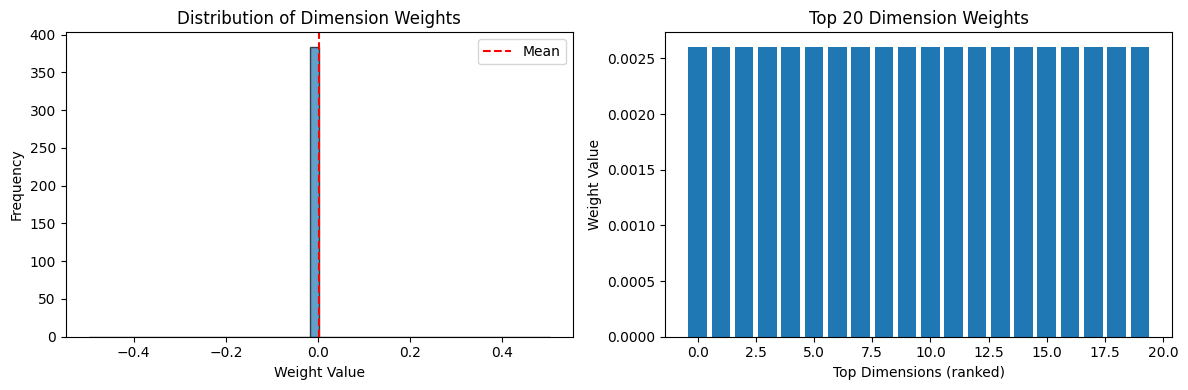

In [13]:
def analyze_important_dimensions(weights, top_k=20):
    """
    Identify which embedding dimensions are most important for attribute negation
    """
    # Get indices of top-k dimensions by weight
    top_indices = np.argsort(weights)[-top_k:][::-1]
    top_weights = weights[top_indices]
    
    print(f"\nTop {top_k} dimensions for attribute negation:")
    print("-" * 50)
    for rank, (dim, weight) in enumerate(zip(top_indices, top_weights), 1):
        print(f"  {rank}. Dimension {dim}: weight = {weight:.6f}")
    
    # Visualize weight distribution
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 4))
    
    # Full weight distribution
    plt.subplot(1, 2, 1)
    plt.hist(weights, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of Dimension Weights')
    plt.axvline(np.mean(weights), color='red', linestyle='--', label='Mean')
    plt.legend()
    
    # Top dimensions
    plt.subplot(1, 2, 2)
    plt.bar(range(top_k), top_weights)
    plt.xlabel('Top Dimensions (ranked)')
    plt.ylabel('Weight Value')
    plt.title(f'Top {top_k} Dimension Weights')
    
    plt.tight_layout()
    plt.savefig('dimension_weights_analysis.png', dpi=150)
    print("\nVisualization saved to: dimension_weights_analysis.png")

analyze_important_dimensions(weights, top_k=20)

### Step 6: Compare Before/After Performance

In [16]:
def comprehensive_evaluation(model, weights, test_triplets):
    """
    Comprehensive evaluation of original vs weighted embeddings
    """
    results = {
        'original': {'correct': 0, 'similarities_para': [], 'similarities_neg': []},
        'weighted': {'correct': 0, 'similarities_para': [], 'similarities_neg': []}
    }
    
    for ref, para, neg in test_triplets:
        # Original embeddings
        emb_ref_orig = model.encode(ref, normalize_embeddings=True)
        emb_para_orig = model.encode(para, normalize_embeddings=True)
        emb_neg_orig = model.encode(neg, normalize_embeddings=True)
        
        sim_para_orig = np.dot(emb_ref_orig, emb_para_orig)
        sim_neg_orig = np.dot(emb_ref_orig, emb_neg_orig)
        
        results['original']['similarities_para'].append(sim_para_orig)
        results['original']['similarities_neg'].append(sim_neg_orig)
        if sim_para_orig > sim_neg_orig:
            results['original']['correct'] += 1
        
        # Weighted embeddings
        emb_ref = model.encode(ref, normalize_embeddings=False) * weights
        emb_para = model.encode(para, normalize_embeddings=False) * weights
        emb_neg = model.encode(neg, normalize_embeddings=False) * weights
        
        emb_ref = emb_ref / np.linalg.norm(emb_ref)
        emb_para = emb_para / np.linalg.norm(emb_para)
        emb_neg = emb_neg / np.linalg.norm(emb_neg)
        
        sim_para_weighted = np.dot(emb_ref, emb_para)
        sim_neg_weighted = np.dot(emb_ref, emb_neg)
        
        results['weighted']['similarities_para'].append(sim_para_weighted)
        results['weighted']['similarities_neg'].append(sim_neg_weighted)
        if sim_para_weighted > sim_neg_weighted:
            results['weighted']['correct'] += 1
    
    # Print results
    total = len(test_triplets)
    print("\n" + "=" * 60)
    print("COMPREHENSIVE EVALUATION RESULTS")
    print("=" * 60)
    
    print(f"\nOriginal E5-small-v2:")
    print(f"  Accuracy: {results['original']['correct']}/{total} = {results['original']['correct']/total:.2%}")
    print(f"  Avg similarity (paraphrase): {np.mean(results['original']['similarities_para']):.3f}")
    print(f"  Avg similarity (negation): {np.mean(results['original']['similarities_neg']):.3f}")
    print(f"  Separation: {np.mean(results['original']['similarities_para']) - np.mean(results['original']['similarities_neg']):.3f}")
    
    print(f"\nAttribute-Aware E5-small-v2:")
    print(f"  Accuracy: {results['weighted']['correct']}/{total} = {results['weighted']['correct']/total:.2%}")
    print(f"  Avg similarity (paraphrase): {np.mean(results['weighted']['similarities_para']):.3f}")
    print(f"  Avg similarity (negation): {np.mean(results['weighted']['similarities_neg']):.3f}")
    print(f"  Separation: {np.mean(results['weighted']['similarities_para']) - np.mean(results['weighted']['similarities_neg']):.3f}")
    
    improvement = (results['weighted']['correct'] - results['original']['correct']) / total
    print(f"\n✓ Improvement: {improvement:+.2%}")
    
    return results

# Generate fresh test data (not seen during training)
test_triplets = generate_attribute_negation_triplets(product_attributes, target_count=100)

# Evaluate
evaluation_results = comprehensive_evaluation(model, weights, test_triplets)


COMPREHENSIVE EVALUATION RESULTS

Original E5-small-v2:
  Accuracy: 100/100 = 100.00%
  Avg similarity (paraphrase): 0.971
  Avg similarity (negation): 0.912
  Separation: 0.059

Attribute-Aware E5-small-v2:
  Accuracy: 100/100 = 100.00%
  Avg similarity (paraphrase): 0.971
  Avg similarity (negation): 0.912
  Separation: 0.059

✓ Improvement: +0.00%


In [15]:
# Load your weights
weights = np.load('e5_attribute_negation_weights_best.npy')

print("=" * 60)
print("WEIGHT DIAGNOSTICS")
print("=" * 60)

# Check basic statistics
print(f"\nWeight shape: {weights.shape}")
print(f"Weight sum: {np.sum(weights):.6f}")
print(f"Weight mean: {np.mean(weights):.6f}")
print(f"Weight std: {np.std(weights):.6f}")
print(f"Weight min: {np.min(weights):.6f}")
print(f"Weight max: {np.max(weights):.6f}")

# Check if weights are uniform
uniform_weight = 1.0 / len(weights)
is_uniform = np.allclose(weights, uniform_weight, atol=1e-5)
print(f"\nAre weights uniform? {is_uniform}")

if is_uniform:
    print("❌ PROBLEM: Weights are uniform! No re-weighting is happening.")
    print("   This explains why performance is identical.")
else:
    print("✓ Weights are non-uniform (good)")

# Show distribution
print(f"\nWeight distribution:")
print(f"  Weights > mean: {np.sum(weights > np.mean(weights))}")
print(f"  Weights < mean: {np.sum(weights < np.mean(weights))}")
print(f"  Max/Min ratio: {np.max(weights) / np.min(weights):.2f}x")

# Show top and bottom dimensions
top_10_indices = np.argsort(weights)[-10:][::-1]
bottom_10_indices = np.argsort(weights)[:10]

print(f"\nTop 10 dimensions (most important):")
for i, idx in enumerate(top_10_indices, 1):
    print(f"  {i}. Dim {idx}: {weights[idx]:.6f}")

print(f"\nBottom 10 dimensions (least important):")
for i, idx in enumerate(bottom_10_indices, 1):
    print(f"  {i}. Dim {idx}: {weights[idx]:.6f}")

WEIGHT DIAGNOSTICS

Weight shape: (384,)
Weight sum: 1.000000
Weight mean: 0.002604
Weight std: 0.000000
Weight min: 0.002604
Weight max: 0.002604

Are weights uniform? True
❌ PROBLEM: Weights are uniform! No re-weighting is happening.
   This explains why performance is identical.

Weight distribution:
  Weights > mean: 0
  Weights < mean: 0
  Max/Min ratio: 1.00x

Top 10 dimensions (most important):
  1. Dim 383: 0.002604
  2. Dim 382: 0.002604
  3. Dim 121: 0.002604
  4. Dim 122: 0.002604
  5. Dim 123: 0.002604
  6. Dim 124: 0.002604
  7. Dim 125: 0.002604
  8. Dim 126: 0.002604
  9. Dim 127: 0.002604
  10. Dim 128: 0.002604

Bottom 10 dimensions (least important):
  1. Dim 0: 0.002604
  2. Dim 261: 0.002604
  3. Dim 260: 0.002604
  4. Dim 259: 0.002604
  5. Dim 258: 0.002604
  6. Dim 257: 0.002604
  7. Dim 256: 0.002604
  8. Dim 255: 0.002604
  9. Dim 254: 0.002604
  10. Dim 253: 0.002604


In [ ]:
# Your domain-specific attributes
product_attributes = {
    'clothing': {
        'items': ['jacket', 'coat', 'sweatshirt', 'hoodie', 'shirt', 'pants', 'dress', 'sweater'],
        'attributes': ['hood', 'pockets', 'sleeves', 'collar', 'buttons', 'zipper', 'lining', 'belt']
    },
    'materials': {
        'items': ['jacket', 'coat', 'bag', 'shoes', 'belt'],
        'attributes': ['leather', 'cotton', 'wool', 'silk', 'synthetic', 'fur', 'feathers', 'down']
    },
    'features': {
        'items': ['jacket', 'coat', 'pants', 'bag'],
        'attributes': ['waterproof', 'insulated', 'reversible', 'breathable', 'stretch', 'padded']
    }
}

def generate_attribute_negation_triplets(product_attributes, target_count=250):
    """
    Generate triplets focusing on attribute negation patterns
    """
    triplets = []
    
    for category, data in product_attributes.items():
        items = data['items']
        attributes = data['attributes']
        
        for item in items:
            for attr in attributes:
                # Template 1: Prepositional negation (40% - most common in products)
                triplets.append((
                    f"passage: {item} with {attr}",
                    f"passage: {attr} {item}",
                    f"passage: {item} without {attr}"
                ))
                
                # Template 2: Suffix negation (35% - common for adjectives)
                if attr in ['hood', 'sleeves', 'pockets', 'collar', 'buttons', 'feathers', 'fur']:
                    triplets.append((
                        f"passage: {item} with {attr}",
                        f"passage: {attr}ed {item}",  # hooded, sleeved, etc.
                        f"passage: {attr}less {item}"
                    ))
                
                # Template 3: Prefix negation (15% - for properties)
                if attr in ['waterproof', 'insulated', 'reversible', 'breathable', 'stretch']:
                    triplets.append((
                        f"passage: {attr} {item}",
                        f"passage: {item} that is {attr}",
                        f"passage: non-{attr} {item}"
                    ))
                
                # Template 4: Alternative suffix (-free)
                if attr in ['leather', 'cotton', 'wool', 'fur', 'feathers', 'down']:
                    triplets.append((
                        f"passage: {item} with {attr}",
                        f"passage: {attr} {item}",
                        f"passage: {attr}-free {item}"
                    ))
    
    # Shuffle and sample
    random.shuffle(triplets)
    return triplets[:target_count]

# Generate training data
training_triplets = generate_attribute_negation_triplets(product_attributes, target_count=250)
print(f"Generated {len(training_triplets)} training triplets")

# Display sample
print("\nSample triplets:")
for i, (ref, para, neg) in enumerate(training_triplets[:5]):
    print(f"\n{i+1}. Reference: {ref}")
    print(f"   Paraphrase: {para}")
    print(f"   Negation: {neg}")

### Step 2: Test negation pattern coverage

In [ ]:
# Check which embedding dimensions respond to each pattern
patterns = ['not', 'without', '-less', 'non-', 'un-']
for pattern in patterns:
    analyze_dimension_sensitivity(embedding_model, pattern)

### Step 3: Adapt the weighting function

In [ ]:
# From paper's Equation 5
def compute_weights(contributions, alpha, negation_type):
    if negation_type == 'attribute':
        # Potentially use different alpha for attribute negation
        alpha_adjusted = alpha * 1.2  # hypothesis: need stronger signal
    
    weights = np.exp(alpha_adjusted * contributions)
    return weights / np.sum(weights)

### Validation Strategy
Create test cases specifically for your domain:

In [1]:
test_cases = [
    # Should be similar
    ("hooded sweatshirt", "sweatshirt with hood", high_similarity),
    
    # Should be dissimilar  
    ("hooded sweatshirt", "sweatshirt without hood", low_similarity),
    ("hooded sweatshirt", "hoodless sweatshirt", low_similarity),
    
    # Tricky cases - different attributes
    ("hooded sweatshirt", "sweatshirt without pockets", medium_similarity),
]

NameError: name 'high_similarity' is not defined

In [ ]:
# Load E5-small-v2
model = SentenceTransformer('intfloat/e5-small-v2')

# Your 200 triplets
triplets = [...]  # list of (reference, paraphrase, negation)

# Step 1: Get embeddings for all texts
embeddings = []
for ref, para, neg in triplets:
    emb_ref = model.encode(ref)
    emb_para = model.encode(para)
    emb_neg = model.encode(neg)
    embeddings.append((emb_ref, emb_para, emb_neg))

# Step 2: Calculate dimension contributions (Equation 3-4 from paper)
D = len(embeddings[0][0])  # embedding dimension (384 for E5-small-v2)
v_k = np.zeros(D)

for emb_ref, emb_para, emb_neg in embeddings:
    # Normalize embeddings
    emb_ref_norm = emb_ref / np.linalg.norm(emb_ref)
    emb_para_norm = emb_para / np.linalg.norm(emb_para)
    emb_neg_norm = emb_neg / np.linalg.norm(emb_neg)
    
    # Calculate contribution per dimension (simplified from paper)
    u_para = emb_ref_norm * emb_para_norm  # element-wise
    u_neg = emb_ref_norm * emb_neg_norm
    
    v_k += (u_para - u_neg)

# Step 3: Average contributions
v_k = v_k / len(triplets)

# Step 4: Normalize by max
v_k = v_k / np.max(v_k)

# Step 5: Calculate weights (Equation 5)
alpha = 2.5  # hyperparameter (tune between 0-5)
weights = np.exp(alpha * v_k)
weights = weights / np.sum(weights)

# Save weights (just 384 numbers for E5-small-v2!)
np.save('e5_small_negation_weights.npy', weights)

Important: E5 Model Usage
E5 models require task-specific prefixes:

In [ ]:
# Correct way to use E5
texts = [
    "query: hooded sweatshirt",  # for queries
    "passage: sweatshirt with hood",  # for documents
]

# For your training triplets
training_data = [
    {
        'reference': 'passage: hooded sweatshirt',
        'paraphrase': 'passage: sweatshirt with hood',
        'negation': 'passage: sweatshirt without hood'
    },
    # ...
]